# Electron orbitals — shapes, fill order, metals

**Chemistry HL - Structure 1.3**

A longer walkthrough in four parts:
1. What **s** and the three **p** orbitals look like
2. Two electrons per orbital (Pauli)
3. Periodic-table blocks and the **diagonal Aufbau** fill order
4. Transition metals — and the **Cr / Cu** exceptions

The website page is the interactive version of the same material.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from matplotlib.patches import Circle, FancyArrowPatch

ACCENT, INK, SOFT = "#b4341f", "#1a1a1a", "#6b6b6b"
P_POS, P_NEG = "#2f6f8f", "#c47a1a"

AUFBAU = [
    (1, "s", 2),
    (2, "s", 2), (2, "p", 6),
    (3, "s", 2), (3, "p", 6),
    (4, "s", 2), (3, "d", 10), (4, "p", 6),
    (5, "s", 2), (4, "d", 10), (5, "p", 6),
    (6, "s", 2), (4, "f", 14), (5, "d", 10), (6, "p", 6),
]
EXCEPTIONS = {24: {"4s": 1, "3d": 5}, 29: {"4s": 1, "3d": 10}}

In [2]:
def fill_aufbau(z, apply_exception=True):
    remaining, config = z, {}
    for n, letter, cap in AUFBAU:
        if remaining <= 0:
            break
        key = f"{n}{letter}"
        take = min(cap, remaining)
        config[key] = take
        remaining -= take
    if apply_exception and z in EXCEPTIONS:
        config.update(EXCEPTIONS[z])
    return config


def config_string(config):
    order = [f"{n}{L}" for n, L, _ in AUFBAU]
    cores = [(2, "[He]"), (10, "[Ne]"), (18, "[Ar]"), (36, "[Kr]")]
    z = sum(config.values())
    core_z, core_label = 0, ""
    for cz, label in cores:
        if z > cz:
            core_z, core_label = cz, label
    if not core_label:
        return " ".join(f"{k}{config[k]}" for k in order if config.get(k))
    core_cfg = fill_aufbau(core_z, apply_exception=False)
    valence = [f"{k}{config[k]}" for k in order
               if k in config and config[k] != core_cfg.get(k, 0)]
    return f"{core_label} " + " ".join(valence)


def valence_keys(config):
    z = sum(config.values())
    cores = [2, 10, 18, 36]
    core_z = max((c for c in cores if z > c), default=0)
    core_cfg = fill_aufbau(core_z, apply_exception=False) if core_z else {}
    order = [f"{n}{L}" for n, L, _ in AUFBAU]
    return [k for k in order if k in config and config[k] != core_cfg.get(k, 0)]


def occupancy(n_orb, electrons):
    occ = [0] * n_orb
    for e in range(min(electrons, n_orb)):
        occ[e] = 1
    for e in range(n_orb, electrons):
        occ[e - n_orb] = 2
    return occ

## 1. Shapes — s, pₓ, pᵧ, p_z

s is a sphere. Each p orbital is a dumbbell along one axis (x, y or z).
Every orbital holds at most **two electrons of opposite spin** (↑↓).

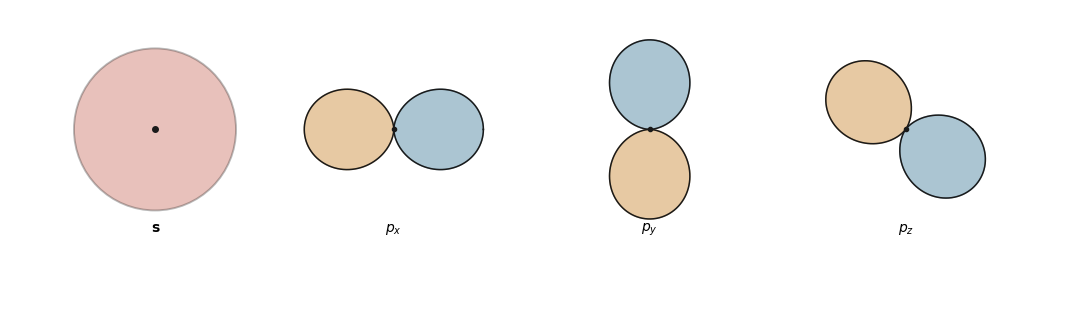

In [3]:
def lobe_path(cx, cy, axis, sign, scale):
    t = np.linspace(0, 2 * np.pi, 400)
    r = scale * np.maximum(0, sign * np.cos(t - axis)) ** 1.35
    return cx + r * np.cos(t), cy + r * np.sin(t)


fig, ax = plt.subplots(figsize=(11, 3.2))
ax.set_xlim(-0.5, 12); ax.set_ylim(-1.8, 1.6); ax.set_aspect("equal"); ax.axis("off")

ax.add_patch(Circle((1.2, 0.2), 0.95, facecolor=ACCENT, edgecolor=INK, alpha=0.3, lw=1.4))
ax.plot(1.2, 0.2, "o", color=INK, ms=4)
ax.text(1.2, -1.0, "s", ha="center", fontweight="bold")

for cx, axis, lab in [(4.0, 0, r"$p_x$"), (7.0, np.pi/2, r"$p_y$"), (10.0, -np.pi/5, r"$p_z$")]:
    for sign, color in ((1, P_POS), (-1, P_NEG)):
        x, y = lobe_path(cx, 0.2, axis, sign, 1.05)
        ax.fill(x, y, color=color, alpha=0.4); ax.plot(x, y, color=INK, lw=1.1)
    ax.plot(cx, 0.2, "o", color=INK, ms=3)
    ax.text(cx, -1.0, lab, ha="center", fontweight="bold")

plt.tight_layout(); plt.show()

## 2. Two electrons per orbital

Pauli: at most two electrons in one orbital, opposite spins. Hund: for p/d/f,
put one in each box before pairing.

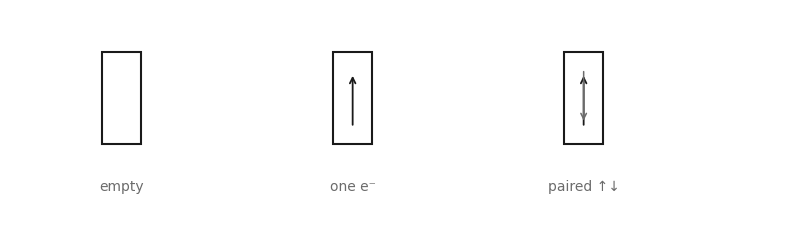

In [4]:
def draw_box(ax, x, y, occ):
    ax.add_patch(mpatches.Rectangle((x, y), 0.5, 1.1, fill=False, edgecolor=INK, lw=1.5))
    if occ >= 1:
        ax.annotate("", xy=(x+0.25, y+0.85), xytext=(x+0.25, y+0.2),
                    arrowprops=dict(arrowstyle="->", color=INK, lw=1.3))
    if occ == 2:
        ax.annotate("", xy=(x+0.25, y+0.25), xytext=(x+0.25, y+0.9),
                    arrowprops=dict(arrowstyle="->", color=SOFT, lw=1.1))

fig, ax = plt.subplots(figsize=(8, 2.4))
ax.set_xlim(0, 10); ax.set_ylim(0, 2.5); ax.axis("off")
for i, (occ, lab) in enumerate(zip([0, 1, 2], ["empty", "one e⁻", "paired ↑↓"])):
    x = 1.2 + i * 3
    draw_box(ax, x, 0.9, occ)
    ax.text(x + 0.25, 0.35, lab, ha="center", color=SOFT)
plt.tight_layout(); plt.show()

## 3. Diagonal fill order

Electrons fill by the Madelung / diagonal rule — **4s before 3d**, which is why
the d-block (transition metals) starts after Ca.

In [5]:
print("Fill order:")
print(" → ".join(f"{n}{L}" for n, L, _ in AUFBAU))
print()
print("So after [Ar] comes 4s (K, Ca), then 3d (Sc → Zn).")

Fill order:
1s → 2s → 2p → 3s → 3p → 4s → 3d → 4p → 5s → 4d → 5p → 6s → 4f → 5d → 6p

So after [Ar] comes 4s (K, Ca), then 3d (Sc → Zn).


## 4. Metals and exceptions — *why* Cr and Cu

Fe follows Aufbau. Cr and Cu do not.

**Why a half-full / full d sublevel can win:**
1. After Ca, **4s and 3d are very close in energy**, so moving one electron between them is cheap.
2. **Exchange energy** (Hund): parallel-spin electrons in different orbitals lower the energy. Half-full **d⁵** has five unpaired d electrons — maximum exchange for the d set. Full **d¹⁰** is a closed, symmetrical sublevel with lower repulsion.
3. **Tradeoff:** the small cost of 4s → 3d is paid back by that stabilisation — enough for Cr and Cu, not for neighbours like Sc, Fe, or Zn.

So Cr is `[Ar] 4s¹ 3d⁵` (not `4s² 3d⁴`), and Cu is `[Ar] 4s¹ 3d¹⁰` (not `4s² 3d⁹`).

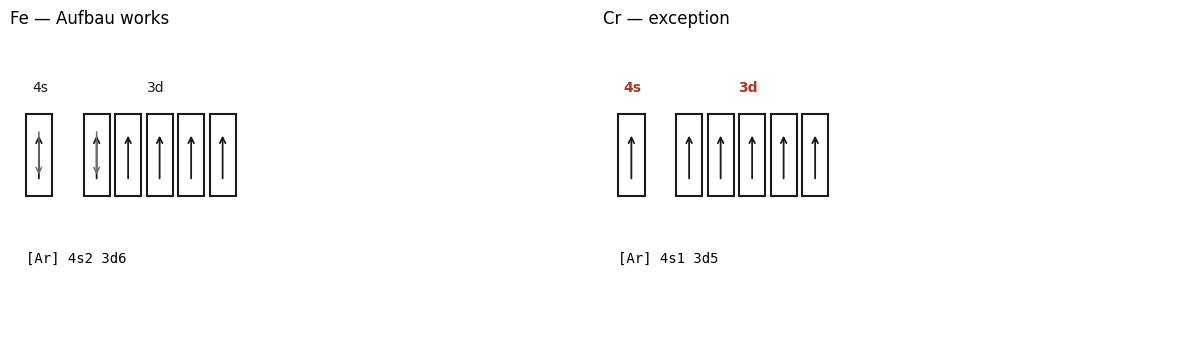

Fe: [Ar] 4s2 3d6           (Aufbau alone: [Ar] 4s2 3d6)
Cr: [Ar] 4s1 3d5           (Aufbau alone: [Ar] 4s2 3d4)  ← exception
Cu: [Ar] 4s1 3d10          (Aufbau alone: [Ar] 4s2 3d9)  ← exception
Zn: [Ar] 4s2 3d10          (Aufbau alone: [Ar] 4s2 3d10)


In [6]:
def draw_config(ax, config, title, highlight=None):
    ax.axis("off"); ax.set_xlim(0, 11); ax.set_ylim(0, 4); ax.set_title(title, loc="left")
    x = 0.3
    for key in valence_keys(config):
        n_orb = {"s": 1, "p": 3, "d": 5, "f": 7}[key[1]]
        occ = occupancy(n_orb, config.get(key, 0))
        hot = bool(highlight and key in highlight)
        ax.text(x + n_orb * 0.55 / 2, 3.2, key, ha="center",
                color=ACCENT if hot else INK, fontweight="bold" if hot else "normal")
        for i, n in enumerate(occ):
            draw_box(ax, x + i * 0.6, 1.8, n)
        x += n_orb * 0.6 + 0.5
    ax.text(0.3, 0.9, config_string(config), fontfamily="monospace")

fig, (a, b) = plt.subplots(1, 2, figsize=(12, 3.5))
draw_config(a, fill_aufbau(26), "Fe — Aufbau works")
draw_config(b, fill_aufbau(24), "Cr — exception", highlight={"4s", "3d"})
plt.tight_layout(); plt.show()

for z, sym in [(26, "Fe"), (24, "Cr"), (29, "Cu"), (30, "Zn")]:
    naive = config_string(fill_aufbau(z, apply_exception=False))
    actual = config_string(fill_aufbau(z))
    mark = "  ← exception" if naive != actual else ""
    print(f"{sym}: {actual:<22} (Aufbau alone: {naive}){mark}")